# Evaluación de Resultados: M5 Forecasting

---
## 1. Configuración e imports

In [1]:
%pip install lightgbm xgboost prophet pmdarima scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

warnings.filterwarnings('ignore')
sns.set_palette('muted')

# Paleta y marcadores consistentes en todas las figuras
MODEL_COLORS = {
    'Naïve':        '#4878d0',
    'SARIMA':       '#ee854a',
    'SARIMAX':      '#c44e52',
    'LightGBM':     '#6acc65',
    'XGBoost':      '#8172b3',
    'RandomForest': '#937860',
    'Prophet':      '#da8bc3',
    'LGB_Global':   '#64b5cd',
}
MODEL_MRK = {
    'Naïve': 'o', 'SARIMA': 's', 'SARIMAX': 'D',
    'LightGBM': '^', 'XGBoost': 'v', 'RandomForest': 'P',
    'Prophet': 'X', 'LGB_Global': '*',
}

# Estilo global académico
plt.rcParams.update({
    'figure.figsize'    : (13, 5),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.35,
    'axes.axisbelow'    : True,
    'font.size'         : 11,
    'axes.labelsize'    : 11,
    'axes.titlesize'    : 12,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 9,
    'legend.framealpha' : 0.75,
})

FIGURES_DIR = Path('imagenes/media')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path('data/m5')

H = 28          # horizonte de predicción en días
RANDOM_STATE = 42

print(f'Horizonte de predicción : {H} días')
print(f'Figuras en              : {FIGURES_DIR.resolve()}')
print(f'Python env OK           : lightgbm={lgb.__version__}')

Horizonte de predicción : 28 días
Figuras en              : C:\Users\chavju01\Documents\Maestria\semestre3\trabajo_final\imagenes\media
Python env OK           : lightgbm=4.6.0


---
## 2. Carga de datos y series representativas

In [3]:
print('Cargando datos...')
sales       = pd.read_csv(DATA_DIR / 'sales_train_validation.csv')
calendar    = pd.read_csv(DATA_DIR / 'calendar.csv', parse_dates=['date'])
sell_prices = pd.read_csv(DATA_DIR / 'sell_prices.csv')

id_cols  = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
day_cols = [c for c in sales.columns if c.startswith('d_')]
n_days   = len(day_cols)       # 1913
TRAIN_DAYS = n_days - H        # 1885

# Enriquecer calendario
calendar['snap_CA']    = calendar['snap_CA'].astype(int)
calendar['has_event']  = (~calendar['event_type_1'].isna()).astype(int)
calendar['day_num']    = calendar['d'].str.replace('d_', '', regex=False).astype(int)

print(f'Series         : {len(sales):,}')
print(f'Días totales   : {n_days:,}   (d_1 – d_{n_days})')
print(f'Entrenamiento  : d_1  – d_{TRAIN_DAYS}  ({TRAIN_DAYS} días)')
print(f'Validación     : d_{TRAIN_DAYS+1} – d_{n_days}  ({H} días)')

Cargando datos...
Series         : 30,490
Días totales   : 1,913   (d_1 – d_1913)
Entrenamiento  : d_1  – d_1885  (1885 días)
Validación     : d_1886 – d_1913  (28 días)


In [4]:
# Selección: mismas 4 series representativas que en E2
pct_ceros = (sales[day_cols] == 0).mean(axis=1)

rep_series = {}
for cat in ['FOODS', 'HOUSEHOLD', 'HOBBIES']:
    mask = (sales['cat_id'] == cat) & (sales['store_id'] == 'CA_1')
    best = sales[mask].loc[(pct_ceros[mask]).idxmin()]
    rep_series[cat] = best['id']
    print(f'{cat:<10}: {best["id"]}  (% ceros: {pct_ceros[best.name]*100:.1f}%)')

rep_series['FOODS_CA1_AGG'] = 'FOODS_CA1_AGG'
print(f'{"AGGREGATE":<10}: FOODS CA_1 (suma de todas las series FOODS en CA_1)')

# Fechas del período de validación
val_dates = calendar[calendar['day_num'].between(TRAIN_DAYS + 1, n_days)]['date'].values
print(f'\nFecha inicio validación : {val_dates[0]}')
print(f'Fecha fin   validación  : {val_dates[-1]}')

FOODS     : FOODS_3_080_CA_1_validation  (% ceros: 0.3%)
HOUSEHOLD : HOUSEHOLD_1_373_CA_1_validation  (% ceros: 5.8%)
HOBBIES   : HOBBIES_1_254_CA_1_validation  (% ceros: 12.3%)
AGGREGATE : FOODS CA_1 (suma de todas las series FOODS en CA_1)

Fecha inicio validación : 2016-03-28T00:00:00.000000000
Fecha fin   validación  : 2016-04-24T00:00:00.000000000


In [5]:
# Funciones auxiliares

def get_series(series_id: str) -> np.ndarray:
    """Extrae una serie temporal como array numpy float64."""
    if series_id == 'FOODS_CA1_AGG':
        y = sales[(sales['cat_id'] == 'FOODS') & (sales['store_id'] == 'CA_1')][day_cols].sum().values
    else:
        y = sales[sales['id'] == series_id][day_cols].values.flatten()
    return y.astype(float)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, label: str = '') -> dict:
    """RMSE, MAE y MAPE (solo posiciones con y_true > 0)."""
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mask = y_true > 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.sum() > 0 else np.nan
    if label:
        print(f'    {label:<16}  RMSE={rmse:7.3f}  MAE={mae:7.3f}  MAPE={mape:5.1f}%')
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


# Feature engineering (tabular)
FEATURE_COLS = [
    'lag_28', 'lag_35', 'lag_42', 'lag_49', 'lag_56',
    'roll_mean_28', 'roll_mean_7',
    'wday', 'month', 'snap_CA', 'has_event',
]

def make_tabular_dataset(y_arr: np.ndarray, calendar_df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye dataset tabular con features de lag (offset >= 28 días).
    Empieza en t=56 para que lag_56 esté siempre disponible.
    """
    cal = calendar_df[['day_num', 'wday', 'month', 'snap_CA', 'has_event']].set_index('day_num')
    n = len(y_arr)
    records = []
    for t in range(56, n):
        dn = t + 1  # 1-indexed
        rec = {
            'day_num'      : dn,
            'target'       : y_arr[t],
            'lag_28'       : y_arr[t - 28],
            'lag_35'       : y_arr[t - 35],
            'lag_42'       : y_arr[t - 42],
            'lag_49'       : y_arr[t - 49],
            'lag_56'       : y_arr[t - 56],
            'roll_mean_28' : float(np.mean(y_arr[t - 56 : t - 28])),
            'roll_mean_7'  : float(np.mean(y_arr[t - 35 : t - 28])),
        }
        if dn in cal.index:
            cr = cal.loc[dn]
            rec['wday']      = int(cr['wday'])
            rec['month']     = int(cr['month'])
            rec['snap_CA']   = int(cr['snap_CA'])
            rec['has_event'] = int(cr['has_event'])
        else:
            rec['wday'] = rec['month'] = rec['snap_CA'] = rec['has_event'] = 0
        records.append(rec)

    return pd.DataFrame(records)


print('Funciones auxiliares y feature engineering definidos.')
print(f'Features tabular: {FEATURE_COLS}')

Funciones auxiliares y feature engineering definidos.
Features tabular: ['lag_28', 'lag_35', 'lag_42', 'lag_49', 'lag_56', 'roll_mean_28', 'roll_mean_7', 'wday', 'month', 'snap_CA', 'has_event']


Generando scatter precio vs. ventas...

Correlación precio–ventas por categoría 

  FOODS         r = -0.218   pendiente = -2.442 u/$
  HOUSEHOLD     r = -0.270   pendiente = -0.804 u/$
  HOBBIES       r = -0.137   pendiente = -0.234 u/$


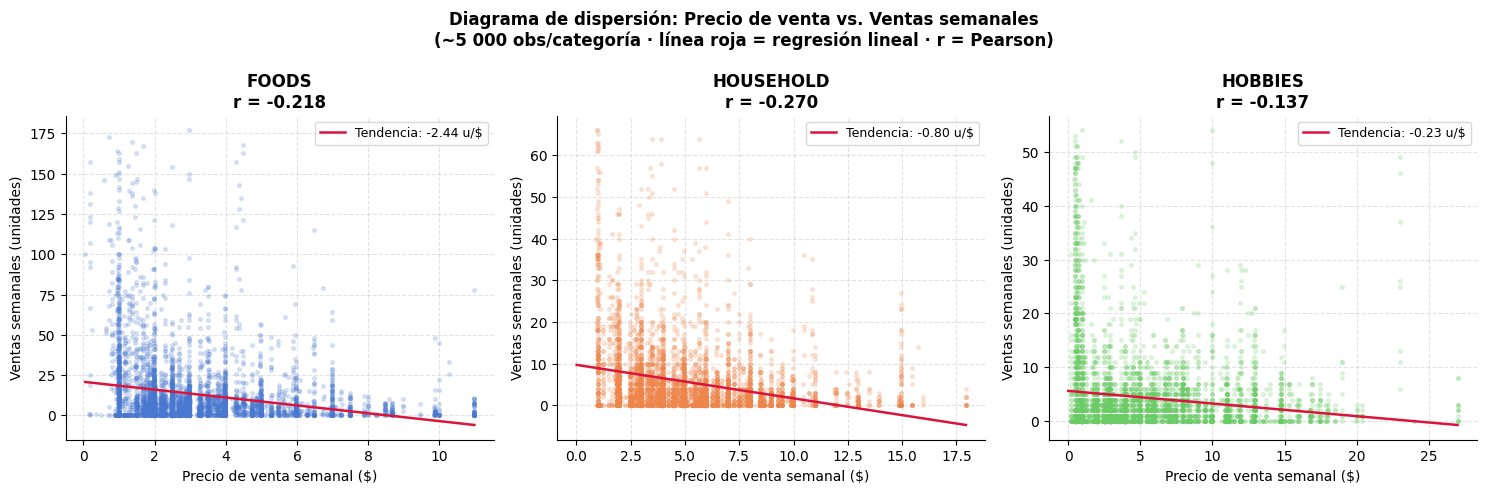


 fig_scatter_precio_ventas.png guardada.
r negativo -> mayor precio asociado a menores ventas (relación precio-demanda esperada).
r ≈ 0 en FOODS -> demanda relativamente inelástica al precio en el corto plazo semanal.


In [6]:
# EDA extra (retroalimentación E2): scatter precio vs. ventas
# Genera: fig_scatter_precio_ventas.png
# Estrategia eficiente en RAM: muestrea items antes de procesar
print('Generando scatter precio vs. ventas...')

import gc

rng_sc = np.random.default_rng(42)
CATS_EDA   = ['FOODS', 'HOUSEHOLD', 'HOBBIES']
COLORS_EDA = {'FOODS': '#4878d0', 'HOUSEHOLD': '#ee854a', 'HOBBIES': '#6acc65'}
N_ITEMS_CAT = 300   # items únicos por categoría → suficiente para el scatter

# 1. Mapeo day_num → wm_yr_wk
wk_map = calendar[['day_num', 'wm_yr_wk']].set_index('day_num')['wm_yr_wk'].to_dict()

# 2. Construir scatter procesando una categoría a la vez
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
print('\nCorrelación precio–ventas por categoría \n')

for ax, cat in zip(axes, CATS_EDA):
    # 2a. Subconjunto de items de esta categoría
    items_cat = sales[sales['cat_id'] == cat]['item_id'].unique()
    items_sel = rng_sc.choice(items_cat, size=min(N_ITEMS_CAT, len(items_cat)), replace=False)

    sub_sales = sales[(sales['cat_id'] == cat) & (sales['item_id'].isin(items_sel))].copy()

    # 2b. Melt solo para este subconjunto (~300 items × 10 tiendas × 1913 días = ~5.7 M filas max)
    sub_long = sub_sales[['item_id', 'store_id'] + day_cols].melt(
        id_vars=['item_id', 'store_id'], var_name='d', value_name='units'
    )
    sub_long['day_num'] = sub_long['d'].str.replace('d_', '', regex=False).astype(np.int32)
    sub_long['wm_yr_wk'] = sub_long['day_num'].map(wk_map)
    sub_long.drop(columns=['d', 'day_num'], inplace=True)

    # 2c. Agrega por semana
    weekly = (
        sub_long.groupby(['item_id', 'store_id', 'wm_yr_wk'])['units']
        .sum().reset_index(name='weekly_units')
    )
    del sub_long, sub_sales; gc.collect()

    # 2d. Une con precios
    weekly = weekly.merge(
        sell_prices[['item_id', 'store_id', 'wm_yr_wk', 'sell_price']],
        on=['item_id', 'store_id', 'wm_yr_wk'], how='inner'
    )

    # 2e. Elimina outliers extremos (p99)
    p99_u = np.percentile(weekly['weekly_units'], 99)
    p99_p = np.percentile(weekly['sell_price'],   99)
    weekly = weekly[(weekly['weekly_units'] <= p99_u) & (weekly['sell_price'] <= p99_p)]

    # 2f. Muestra para el scatter (5 000 puntos máximo)
    idx_s = rng_sc.choice(len(weekly), size=min(5_000, len(weekly)), replace=False)
    s = weekly.iloc[idx_s]

    # 2g. Scatter + regresión
    ax.scatter(s['sell_price'], s['weekly_units'],
               alpha=0.18, s=7, color=COLORS_EDA[cat], rasterized=True)

    slope, intercept = np.polyfit(weekly['sell_price'], weekly['weekly_units'], 1)
    x_line = np.linspace(weekly['sell_price'].min(), weekly['sell_price'].max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color='crimson', linewidth=1.8, label=f'Tendencia: {slope:+.2f} u/$')

    corr = weekly[['sell_price', 'weekly_units']].corr().iloc[0, 1]
    ax.set_title(f'{cat}\nr = {corr:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Precio de venta semanal ($)', fontsize=10)
    ax.set_ylabel('Ventas semanales (unidades)', fontsize=10)
    ax.legend(fontsize=9)

    print(f'  {cat:<12}  r = {corr:+.3f}   pendiente = {slope:+.3f} u/$')
    del weekly; gc.collect()

fig.suptitle(
    'Diagrama de dispersión: Precio de venta vs. Ventas semanales\n'
    '(~5 000 obs/categoría · línea roja = regresión lineal · r = Pearson)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_scatter_precio_ventas.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n fig_scatter_precio_ventas.png guardada.')
print('r negativo -> mayor precio asociado a menores ventas (relación precio-demanda esperada).')
print('r ≈ 0 en FOODS -> demanda relativamente inelástica al precio en el corto plazo semanal.')

---
## 3. Modelos E2: Naïve, SARIMA y LightGBM local (reproducción)

Reproducción de los tres modelos entregados en E2 para usarlos como línea de comparación.

In [7]:
# Naïve Estacional s=7
print('Naïve Estacional (s=7)\n')
results_naive = {}
naive_preds   = {}

for name, sid in rep_series.items():
    y       = get_series(sid)
    y_train = y[:TRAIN_DAYS]
    y_val   = y[TRAIN_DAYS:]
    y_pred  = np.tile(y_train[-7:], (H // 7) + 1)[:H]

    results_naive[name] = compute_metrics(y_val, y_pred, label=name)
    naive_preds[name]   = y_pred

print('\nNaïve completado.')

Naïve Estacional (s=7)

    FOODS             RMSE= 12.087  MAE=  9.107  MAPE= 64.4%
    HOUSEHOLD         RMSE=  2.758  MAE=  2.107  MAPE= 62.8%
    HOBBIES           RMSE=  7.702  MAE=  6.036  MAPE=106.8%
    FOODS_CA1_AGG     RMSE=420.116  MAE=343.857  MAPE= 10.9%

Naïve completado.


In [8]:
# SARIMA (auto_arima, m=7)
print('SARIMA (auto_arima, m=7)')
print('Restricciones: max_p=2, max_q=2, max_P=1, max_Q=1, d=1, D=1\n')

results_sarima = {}
sarima_preds   = {}
sarima_orders  = {}

for name, sid in rep_series.items():
    y       = get_series(sid)
    y_train = y[:TRAIN_DAYS]
    y_val   = y[TRAIN_DAYS:]

    print(f'  Ajustando {name}...', end=' ', flush=True)
    model = auto_arima(
        y_train,
        start_p=1, start_q=1,
        max_p=2,   max_q=2,
        m=7,       seasonal=True,
        start_P=0, start_Q=0,
        max_P=1,   max_Q=1,
        d=1,       D=1,
        information_criterion='aic',
        stepwise=True,
        error_action='ignore',
        suppress_warnings=True,
    )
    order = f'SARIMA{model.order}x{model.seasonal_order}'
    print(order)
    sarima_orders[name] = order

    y_pred = np.clip(model.predict(n_periods=H), 0, None)
    results_sarima[name] = compute_metrics(y_val, y_pred, label=name)
    sarima_preds[name]   = y_pred

print('\nSARIMA completado.')

SARIMA (auto_arima, m=7)
Restricciones: max_p=2, max_q=2, max_P=1, max_Q=1, d=1, D=1

  Ajustando FOODS... SARIMA(2, 1, 0)x(1, 1, 0, 7)
    FOODS             RMSE= 12.970  MAE= 10.485  MAPE= 52.6%
  Ajustando HOUSEHOLD... SARIMA(2, 1, 0)x(1, 1, 0, 7)
    HOUSEHOLD         RMSE=  3.228  MAE=  2.727  MAPE=104.7%
  Ajustando HOBBIES... SARIMA(2, 1, 0)x(1, 1, 0, 7)
    HOBBIES           RMSE=  6.310  MAE=  4.785  MAPE= 69.9%
  Ajustando FOODS_CA1_AGG... SARIMA(2, 1, 0)x(1, 1, 0, 7)
    FOODS_CA1_AGG     RMSE=363.402  MAE=300.284  MAPE=  9.8%

SARIMA completado.


In [9]:
# LightGBM local (un modelo por serie)
print('LightGBM Local (200 rondas)\n')

lgb_params = {
    'objective'        : 'regression_l2',
    'metric'           : 'rmse',
    'num_leaves'       : 31,
    'learning_rate'    : 0.05,
    'min_child_samples': 10,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 1,
    'verbose'          : -1,
    'seed'             : RANDOM_STATE,
}

results_lgb = {}
lgb_models  = {}
lgb_preds   = {}

for name, sid in rep_series.items():
    y   = get_series(sid)
    df  = make_tabular_dataset(y, calendar)

    df_train = df[df['day_num'] <= TRAIN_DAYS]
    df_val   = df[(df['day_num'] > TRAIN_DAYS) & (df['day_num'] <= n_days)]

    X_tr, y_tr = df_train[FEATURE_COLS], df_train['target']
    X_v,  y_v  = df_val[FEATURE_COLS],   df_val['target']

    print(f'  {name:<16}  train={len(X_tr):,} | val={len(X_v):,}', end='  ')

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    model  = lgb.train(lgb_params, dtrain, num_boost_round=200,
                       callbacks=[lgb.log_evaluation(0)])

    y_pred = np.clip(model.predict(X_v), 0, None)
    m = compute_metrics(y_v.values, y_pred)
    print(f'RMSE={m["RMSE"]:7.3f}  MAE={m["MAE"]:7.3f}  MAPE={m["MAPE"]:5.1f}%')

    results_lgb[name] = m
    lgb_models[name]  = model
    lgb_preds[name]   = y_pred

print('\nLightGBM local completado.')

LightGBM Local (200 rondas)

  FOODS             train=1,829 | val=28  RMSE=  6.628  MAE=  5.248  MAPE= 33.1%
  HOUSEHOLD         train=1,829 | val=28  RMSE=  2.775  MAE=  2.296  MAPE= 56.8%
  HOBBIES           train=1,829 | val=28  RMSE=  5.521  MAE=  4.714  MAPE=130.6%
  FOODS_CA1_AGG     train=1,829 | val=28  RMSE=216.909  MAE=174.483  MAPE=  6.0%

LightGBM local completado.


In [10]:
# Tabla comparativa E2 (referencia)
print('Tabla de referencia E2 (validación 28 días)\n')
print(f'{"Serie":<16}  {"Naïve":>8}  {"SARIMA":>8}  {"LightGBM":>10}  Mejor')
print('─' * 62)
for name in rep_series:
    r_n = results_naive[name]['RMSE']
    r_s = results_sarima[name]['RMSE']
    r_l = results_lgb[name]['RMSE']
    best = ['Naïve', 'SARIMA', 'LightGBM'][np.argmin([r_n, r_s, r_l])]
    print(f'{name:<16}  {r_n:>8.3f}  {r_s:>8.3f}  {r_l:>10.3f}  {best}')
print('\n[OK] Base E2 reproducida correctamente.')

Tabla de referencia E2 (validación 28 días)

Serie                Naïve    SARIMA    LightGBM  Mejor
──────────────────────────────────────────────────────────────
FOODS               12.087    12.970       6.628  LightGBM
HOUSEHOLD            2.758     3.228       2.775  Naïve
HOBBIES              7.702     6.310       5.521  LightGBM
FOODS_CA1_AGG      420.116   363.402     216.909  LightGBM

[OK] Base E2 reproducida correctamente.


---
## 5. Figura comparativa — modelos estadísticos

Comparación visual de los cuatro modelos estadísticos (Naïve, SARIMA, SARIMAX y Prophet)
para aislar cuál estrategia estadística funciona mejor en cada tipo de serie,
sin mezclar con los modelos de ML.


Generando comparación estadística completa (4 modelos)...


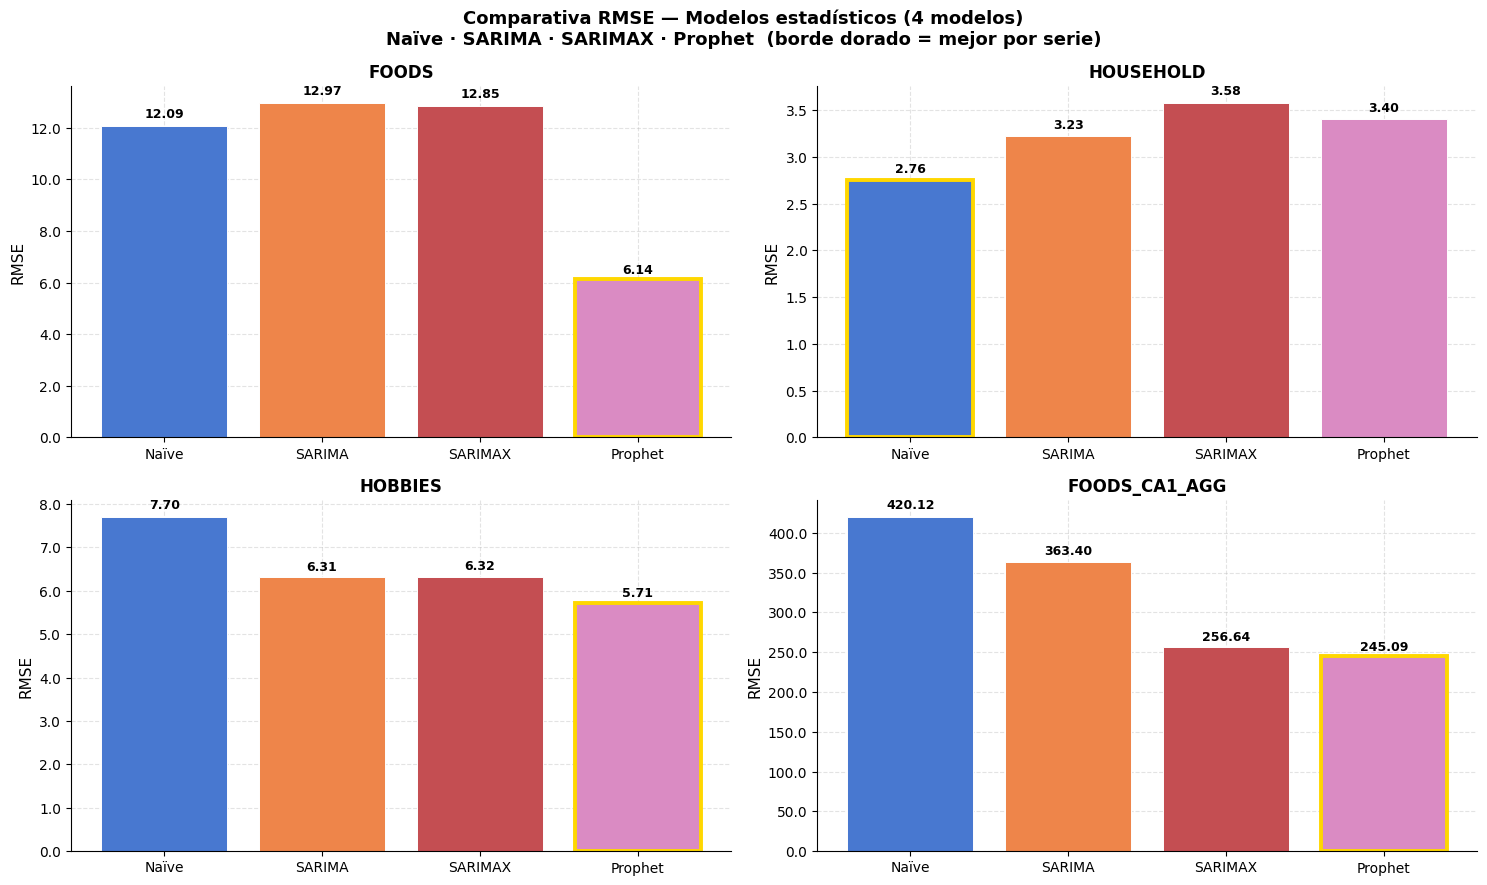

 fig_rmse_estadisticos.png

Modelos estadísticos — RMSE (4 modelos)

Serie                Naïve    SARIMA   SARIMAX   Prophet  Mejor
──────────────────────────────────────────────────────────────────────────
FOODS               12.087    12.970    12.854     6.141  Prophet
HOUSEHOLD            2.758     3.228     3.579     3.402  Naïve
HOBBIES              7.702     6.310     6.316     5.707  Prophet
FOODS_CA1_AGG      420.116   363.402   256.641   245.092  Prophet

Conclusiones:
- Comparación aislada y completa de los 4 modelos estadísticos: OK.
- Modelo con mejor RMSE medio global: Prophet
- Victorias por serie: Naïve=1, SARIMA=0, SARIMAX=0, Prophet=3


In [ ]:
# Figura comparativa: 4 modelos estadísticos (Naïve / SARIMA / SARIMAX / Prophet)
print('Generando comparación estadística completa (4 modelos)...')

if 'rep_series' not in globals():
    raise RuntimeError('No existe rep_series. Ejecuta primero las secciones 1 y 2.')

series_labels = list(rep_series.keys())

# Si Prophet no está calculado aún, entrenarlo aquí para mantener la comparación de 4 modelos
if 'results_prophet' not in globals():
    try:
        from prophet import Prophet
    except Exception as e:
        raise RuntimeError(
            'No se pudo importar Prophet. Instala el paquete `prophet` y vuelve a ejecutar.'
        ) from e

    if 'get_series' not in globals() or 'compute_metrics' not in globals():
        raise RuntimeError('Faltan funciones base (get_series/compute_metrics). Ejecuta primero secciones iniciales.')

    print('results_prophet no existe; entrenando Prophet para las series representativas...')

    cal_dates = calendar[['day_num', 'date']].copy()
    cal_dates['date'] = pd.to_datetime(cal_dates['date'])
    train_dates = cal_dates.loc[cal_dates['day_num'].between(1, TRAIN_DAYS), 'date'].values
    val_dates_local = cal_dates.loc[cal_dates['day_num'].between(TRAIN_DAYS + 1, n_days), 'date'].values

    results_prophet = {}
    prophet_preds = {}

    for name, sid in rep_series.items():
        y = get_series(sid)
        y_train = y[:TRAIN_DAYS]
        y_val = y[TRAIN_DAYS:]

        df_train_prophet = pd.DataFrame({'ds': train_dates, 'y': y_train.astype(float)})

        m_prophet = Prophet(
            weekly_seasonality=True,
            yearly_seasonality=True,
            daily_seasonality=False,
            seasonality_mode='additive',
            changepoint_prior_scale=0.05,
        )
        m_prophet.fit(df_train_prophet)

        future = pd.DataFrame({'ds': val_dates_local})
        y_pred = np.clip(m_prophet.predict(future)['yhat'].values, 0, None)

        results_prophet[name] = compute_metrics(y_val, y_pred, label=name)
        prophet_preds[name] = y_pred

    print('Prophet completado.')

required_models = [
    ('Naïve', 'results_naive'),
    ('SARIMA', 'results_sarima'),
    ('SARIMAX', 'results_sarimax'),
    ('Prophet', 'results_prophet'),
]
missing = [name for name, var in required_models if var not in globals()]
if missing:
    raise RuntimeError(
        'Faltan resultados para la comparación de 4 modelos: '
        + ', '.join(missing)
        + '. Ejecuta completa la sección de modelos estadísticos y vuelve a correr esta celda.'
    )

stat_models = [name for name, _ in required_models]
stat_results = {name: globals()[var] for name, var in required_models}
stat_colors = [MODEL_COLORS.get(k, '#999999') for k in stat_models]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

best_count = {m: 0 for m in stat_models}

for ax, sname in zip(axes, series_labels):
    vals = [stat_results[m][sname]['RMSE'] for m in stat_models]
    bars = ax.bar(stat_models, vals, color=stat_colors, edgecolor='white', linewidth=0.7)

    best_i = int(np.argmin(vals))
    best_model = stat_models[best_i]
    best_count[best_model] += 1

    bars[best_i].set_edgecolor('gold')
    bars[best_i].set_linewidth(2.8)

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + bar.get_height() * 0.015,
            f'{v:.2f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
        )

    ax.set_title(sname, fontsize=12, fontweight='bold')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', labelsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

fig.suptitle(
    'Comparativa RMSE — Modelos estadísticos (4 modelos)\n'
    'Naïve · SARIMA · SARIMAX · Prophet  (borde dorado = mejor por serie)',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_rmse_estadisticos.png', dpi=150, bbox_inches='tight')
plt.show()
print(' fig_rmse_estadisticos.png')

# Tabla resumen estadísticos
print('\nModelos estadísticos — RMSE (4 modelos)\n')
header = f'{"Serie":<16}  ' + '  '.join(f'{m:>8}' for m in stat_models) + '  Mejor'
print(header)
print('─' * max(74, len(header)))
for sname in series_labels:
    vals = [stat_results[m][sname]['RMSE'] for m in stat_models]
    best = stat_models[int(np.argmin(vals))]
    print(f'{sname:<16}  ' + '  '.join(f'{v:>8.3f}' for v in vals) + f'  {best}')

# Conclusiones rápidas
best_global = min(stat_models, key=lambda m: np.mean([stat_results[m][s]['RMSE'] for s in series_labels]))
print('\nConclusiones:')
print('- Comparación aislada y completa de los 4 modelos estadísticos: OK.')
print('- Modelo con mejor RMSE medio global:', best_global)
print('- Victorias por serie:', ', '.join([f"{m}={best_count[m]}" for m in stat_models]))

---
## 4. SARIMAX — Extensión con variables exógenas

Se usa el mismo orden `SARIMA(2,1,0)×(1,1,0)₇` seleccionado por `auto_arima` en la Sección 3,
añadiendo tres regresores exógenos:

| Exógena | Fuente | Justificación |
|---|---|---|
| `sell_price_norm` | `sell_prices.csv` (semanal, normalizada z-score) | Variabilidad de precio correlacionada con demanda |
| `has_event` | `calendar.csv` | Eventos especiales elevan ventas ~8–12% |
| `snap_CA` | `calendar.csv` | Programa SNAP estimula consumo FOODS |

In [12]:
# Preparar exógenas alineadas (día a día)
cal_exog = calendar[['day_num', 'wm_yr_wk', 'has_event', 'snap_CA']].set_index('day_num')

def get_exog(series_id: str) -> pd.DataFrame:
    """
    Devuelve DataFrame (n_days filas) con columnas:
      sell_price_norm, has_event, snap_CA
    Alineado por day_num (1..n_days).
    """
    if series_id == 'FOODS_CA1_AGG':
        item_ids = sales[(sales['cat_id'] == 'FOODS') & (sales['store_id'] == 'CA_1')]['item_id'].unique()
        prices = (
            sell_prices[sell_prices['store_id'].eq('CA_1') & sell_prices['item_id'].isin(item_ids)]
            .groupby('wm_yr_wk')['sell_price'].mean()
            .reset_index()
        )
    else:
        row = sales[sales['id'] == series_id].iloc[0]
        prices = sell_prices[
            (sell_prices['store_id'] == row['store_id']) &
            (sell_prices['item_id']  == row['item_id'])
        ][['wm_yr_wk', 'sell_price']]

    merged = (
        cal_exog.reset_index()
        .merge(prices, on='wm_yr_wk', how='left')
        .set_index('day_num')
        .sort_index()
    )
    # Rellenar NaN de precio (producto aún no disponible al inicio)
    merged['sell_price'] = merged['sell_price'].ffill().bfill()

    # Normalización z-score sobre período de entrenamiento
    p_mean = merged.loc[1:TRAIN_DAYS, 'sell_price'].mean()
    p_std  = merged.loc[1:TRAIN_DAYS, 'sell_price'].std()
    merged['sell_price_norm'] = (merged['sell_price'] - p_mean) / (p_std + 1e-8)

    return merged[['sell_price_norm', 'has_event', 'snap_CA']].loc[1:n_days]


# Verificación rápida
ex = get_exog('FOODS_CA1_AGG')
print(f'Exógenas shape  : {ex.shape}  (esperado: {n_days} x 3)')
print(f'NaN en exógenas : {ex.isna().sum().to_dict()}')
print(ex.iloc[[0, TRAIN_DAYS - 1, TRAIN_DAYS, -1]])

Exógenas shape  : (1913, 3)  (esperado: 1913 x 3)
NaN en exógenas : {'sell_price_norm': 0, 'has_event': 0, 'snap_CA': 0}
         sell_price_norm  has_event  snap_CA
day_num                                     
1              -2.175555          0        0
1885            1.211336          1        0
1886            1.211336          0        0
1913            1.250376          0        0


In [13]:
# Entrenamiento SARIMAX
print('SARIMAX (2,1,0)×(1,1,0)₇ + exog: sell_price_norm, has_event, snap_CA\n')

SARIMAX_ORDER   = (2, 1, 0)
SARIMAX_S_ORDER = (1, 1, 0, 7)

results_sarimax     = {}
sarimax_preds       = {}
sarimax_orders_used = {}

for name, sid in rep_series.items():
    y       = get_series(sid)
    y_train = y[:TRAIN_DAYS]
    y_val   = y[TRAIN_DAYS:]

    exog_all   = get_exog(sid)
    exog_train = exog_all.iloc[:TRAIN_DAYS].values
    exog_val   = exog_all.iloc[TRAIN_DAYS:].values

    print(f'  Ajustando {name}...', end=' ', flush=True)

    fitted = SARIMAX(
        y_train,
        exog=exog_train,
        order=SARIMAX_ORDER,
        seasonal_order=SARIMAX_S_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    order_str = f'SARIMAX{SARIMAX_ORDER}x{SARIMAX_S_ORDER}'
    print(order_str)
    sarimax_orders_used[name] = order_str

    y_pred = np.clip(fitted.forecast(steps=H, exog=exog_val), 0, None)
    results_sarimax[name] = compute_metrics(y_val, y_pred, label=name)
    sarimax_preds[name]   = y_pred

print('\nSARIMAX completado.')

# Comparación SARIMA vs SARIMAX
print('\nSARIMA vs SARIMAX — RMSE (δ = diferencia, negativo = mejora)\n')
print(f'{"Serie":<16}  {"SARIMA":>8}  {"SARIMAX":>8}  {"δ RMSE":>8}  {"δ %":>7}  Mejor')
print('─' * 62)
for name in rep_series:
    r_a = results_sarima[name]['RMSE']
    r_x = results_sarimax[name]['RMSE']
    delta    = r_x - r_a
    delta_pct = delta / r_a * 100
    mejor = 'SARIMAX' if r_x < r_a else 'SARIMA'
    print(f'{name:<16}  {r_a:>8.3f}  {r_x:>8.3f}  {delta:>+8.3f}  {delta_pct:>+6.1f}%  {mejor}')

SARIMAX (2,1,0)×(1,1,0)₇ + exog: sell_price_norm, has_event, snap_CA

  Ajustando FOODS... SARIMAX(2, 1, 0)x(1, 1, 0, 7)
    FOODS             RMSE= 12.854  MAE= 10.277  MAPE= 51.7%
  Ajustando HOUSEHOLD... SARIMAX(2, 1, 0)x(1, 1, 0, 7)
    HOUSEHOLD         RMSE=  3.579  MAE=  3.011  MAPE=121.3%
  Ajustando HOBBIES... SARIMAX(2, 1, 0)x(1, 1, 0, 7)
    HOBBIES           RMSE=  6.316  MAE=  4.796  MAPE= 70.4%
  Ajustando FOODS_CA1_AGG... SARIMAX(2, 1, 0)x(1, 1, 0, 7)
    FOODS_CA1_AGG     RMSE=256.641  MAE=211.558  MAPE=  6.9%

SARIMAX completado.

SARIMA vs SARIMAX — RMSE (δ = diferencia, negativo = mejora)

Serie               SARIMA   SARIMAX    δ RMSE      δ %  Mejor
──────────────────────────────────────────────────────────────
FOODS               12.970    12.854    -0.116    -0.9%  SARIMAX
HOUSEHOLD            3.228     3.579    +0.350   +10.9%  SARIMA
HOBBIES              6.310     6.316    +0.006    +0.1%  SARIMA
FOODS_CA1_AGG      363.402   256.641  -106.761   -29.4%  SARIMAX


---
## 5. XGBoost y Random Forest

Ambos modelos usan el mismo dataset tabular con las 11 features de lag de la Sección 3
(mismas que LightGBM local), lo que garantiza comparación directa y justa.

- **XGBoost:** 500 rondas de boosting, tasa de aprendizaje 0.05, max_depth=6.  
- **Random Forest:** 300 árboles, max_features='sqrt', min_samples_leaf=5.

In [14]:
# XGBoost
print('XGBoost (500 rondas, lr=0.05, max_depth=6)\n')

xgb_params = {
    'objective'        : 'reg:squarederror',
    'eval_metric'      : 'rmse',
    'learning_rate'    : 0.05,
    'max_depth'        : 6,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 5,
    'seed'             : RANDOM_STATE,
    'verbosity'        : 0,
}

results_xgb = {}
xgb_models  = {}
xgb_preds   = {}

for name, sid in rep_series.items():
    y   = get_series(sid)
    df  = make_tabular_dataset(y, calendar)

    df_train = df[df['day_num'] <= TRAIN_DAYS]
    df_val   = df[(df['day_num'] > TRAIN_DAYS) & (df['day_num'] <= n_days)]

    X_tr, y_tr = df_train[FEATURE_COLS].values, df_train['target'].values
    X_v,  y_v  = df_val[FEATURE_COLS].values,   df_val['target'].values

    print(f'  {name:<16}  train={len(X_tr):,} | val={len(X_v):,}', end='  ')

    dtrain_xgb = xgb.DMatrix(X_tr, label=y_tr, feature_names=FEATURE_COLS)
    dval_xgb   = xgb.DMatrix(X_v,             feature_names=FEATURE_COLS)

    model_xgb = xgb.train(
        xgb_params, dtrain_xgb,
        num_boost_round=500,
        verbose_eval=False,
    )

    y_pred = np.clip(model_xgb.predict(dval_xgb), 0, None)
    m = compute_metrics(y_v, y_pred)
    print(f'RMSE={m["RMSE"]:7.3f}  MAE={m["MAE"]:7.3f}  MAPE={m["MAPE"]:5.1f}%')

    results_xgb[name] = m
    xgb_models[name]  = model_xgb
    xgb_preds[name]   = y_pred

print('\nXGBoost completado.')

XGBoost (500 rondas, lr=0.05, max_depth=6)

  FOODS             train=1,829 | val=28  RMSE=  6.928  MAE=  5.491  MAPE= 33.7%
  HOUSEHOLD         train=1,829 | val=28  RMSE=  2.486  MAE=  2.073  MAPE= 55.0%
  HOBBIES           train=1,829 | val=28  RMSE=  5.286  MAE=  4.448  MAPE=127.1%
  FOODS_CA1_AGG     train=1,829 | val=28  RMSE=226.818  MAE=182.420  MAPE=  6.2%

XGBoost completado.


In [15]:
# Random Forest
print('Random Forest (300 árboles, max_features=sqrt)\n')

results_rf = {}
rf_models  = {}
rf_preds   = {}

for name, sid in rep_series.items():
    y   = get_series(sid)
    df  = make_tabular_dataset(y, calendar)

    df_train = df[df['day_num'] <= TRAIN_DAYS]
    df_val   = df[(df['day_num'] > TRAIN_DAYS) & (df['day_num'] <= n_days)]

    X_tr, y_tr = df_train[FEATURE_COLS].values, df_train['target'].values
    X_v,  y_v  = df_val[FEATURE_COLS].values,   df_val['target'].values

    print(f'  {name:<16}  train={len(X_tr):,} | val={len(X_v):,}', end='  ')

    rf = RandomForestRegressor(
        n_estimators=300,
        max_features='sqrt',
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    rf.fit(X_tr, y_tr)

    y_pred = np.clip(rf.predict(X_v), 0, None)
    m = compute_metrics(y_v, y_pred)
    print(f'RMSE={m["RMSE"]:7.3f}  MAE={m["MAE"]:7.3f}  MAPE={m["MAPE"]:5.1f}%')

    results_rf[name] = m
    rf_models[name]  = rf
    rf_preds[name]   = y_pred

print('\nRandom Forest completado.')

Random Forest (300 árboles, max_features=sqrt)

  FOODS             train=1,829 | val=28  RMSE=  6.392  MAE=  5.107  MAPE= 32.4%
  HOUSEHOLD         train=1,829 | val=28  RMSE=  2.734  MAE=  2.160  MAPE= 52.7%
  HOBBIES           train=1,829 | val=28  RMSE=  4.787  MAE=  4.075  MAPE=115.7%
  FOODS_CA1_AGG     train=1,829 | val=28  RMSE=175.488  MAE=136.555  MAPE=  4.5%

Random Forest completado.


In [16]:
# Comparativa XGBoost / RF / LightGBM
print('ML Tabular: LightGBM vs XGBoost vs Random Forest — RMSE\n')
print(f'{"Serie":<16}  {"LightGBM":>10}  {"XGBoost":>8}  {"RandomForest":>12}  Mejor ML')
print('─' * 62)
for name in rep_series:
    r_l = results_lgb[name]['RMSE']
    r_x = results_xgb[name]['RMSE']
    r_r = results_rf[name]['RMSE']
    best_ml = ['LightGBM', 'XGBoost', 'RandomForest'][np.argmin([r_l, r_x, r_r])]
    print(f'{name:<16}  {r_l:>10.3f}  {r_x:>8.3f}  {r_r:>12.3f}  {best_ml}')

# Importancia de variables: XGBoost
print('\nImportancia de variables XGBoost (gain, top-3 por serie)\n')
for name, model in xgb_models.items():
    scores = model.get_score(importance_type='gain')
    top3 = sorted(scores, key=scores.get, reverse=True)[:3]
    print(f'  {name:<16}: {", ".join(top3)}')

# Importancia de variables: Random Forest
print('\nImportancia de variables Random Forest (impurity, top-3 por serie)\n')
for name, rf in rf_models.items():
    imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
    top3 = imp.nlargest(3).index.tolist()
    print(f'  {name:<16}: {", ".join(top3)}')

ML Tabular: LightGBM vs XGBoost vs Random Forest — RMSE

Serie               LightGBM   XGBoost  RandomForest  Mejor ML
──────────────────────────────────────────────────────────────
FOODS                  6.628     6.928         6.392  RandomForest
HOUSEHOLD              2.775     2.486         2.734  XGBoost
HOBBIES                5.521     5.286         4.787  RandomForest
FOODS_CA1_AGG        216.909   226.818       175.488  RandomForest

Importancia de variables XGBoost (gain, top-3 por serie)

  FOODS           : wday, roll_mean_28, has_event
  HOUSEHOLD       : wday, lag_56, lag_28
  HOBBIES         : wday, lag_42, roll_mean_7
  FOODS_CA1_AGG   : lag_28, wday, snap_CA

Importancia de variables Random Forest (impurity, top-3 por serie)

  FOODS           : wday, lag_28, roll_mean_28
  HOUSEHOLD       : wday, lag_56, roll_mean_28
  HOBBIES         : roll_mean_28, roll_mean_7, lag_42
  FOODS_CA1_AGG   : lag_28, lag_35, wday


---
## 6. Prophet

Prophet (Taylor & Letham, 2018) modela tendencia no lineal, estacionalidad semanal y anual,
y efectos de días festivos. Se configura con:

- `seasonality_mode='additive'` (validado por la descomposición STL del EDA)
- Estacionalidad semanal explícita (`weekly_seasonality=True`)
- Tres regresores exógenos: `sell_price_norm`, `has_event`, `snap_CA`
- Festivos de EE.UU. incorporados automáticamente via `add_country_holidays`

In [17]:
# Prophet
print('Prophet (aditivo, estacionalidad semanal + regressores exógenos)\n')

# Fechas de entrenamiento y validación
train_dates = calendar[calendar['day_num'] <= TRAIN_DAYS]['date'].values
all_dates   = calendar[calendar['day_num'] <= n_days]['date'].values

results_prophet = {}
prophet_preds   = {}

for name, sid in rep_series.items():
    y    = get_series(sid)
    exog = get_exog(sid)   # DataFrame con índice day_num

    # DataFrame Prophet formato ds/y
    df_train_p = pd.DataFrame({
        'ds'              : pd.to_datetime(train_dates),
        'y'               : y[:TRAIN_DAYS],
        'sell_price_norm' : exog['sell_price_norm'].iloc[:TRAIN_DAYS].values,
        'has_event'       : exog['has_event'].iloc[:TRAIN_DAYS].values,
        'snap_CA'         : exog['snap_CA'].iloc[:TRAIN_DAYS].values,
    })

    df_future = pd.DataFrame({
        'ds'              : pd.to_datetime(all_dates),
        'sell_price_norm' : exog['sell_price_norm'].values,
        'has_event'       : exog['has_event'].values,
        'snap_CA'         : exog['snap_CA'].values,
    })

    print(f'  Ajustando {name}...', end=' ', flush=True)

    m_prophet = Prophet(
        seasonality_mode='additive',
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False,
        uncertainty_samples=0,   # desactivar intervalos para acelerar
    )
    m_prophet.add_country_holidays(country_name='US')
    m_prophet.add_regressor('sell_price_norm')
    m_prophet.add_regressor('has_event')
    m_prophet.add_regressor('snap_CA')

    m_prophet.fit(df_train_p)

    forecast = m_prophet.predict(df_future)
    y_pred   = np.clip(
        forecast.set_index('ds')['yhat'].iloc[TRAIN_DAYS:].values,
        0, None
    )

    y_val = y[TRAIN_DAYS:]
    m_met = compute_metrics(y_val, y_pred, label=name)
    results_prophet[name] = m_met
    prophet_preds[name]   = y_pred

print('\nProphet completado.')

# Comparativa estadísticos: SARIMA / SARIMAX / Prophet
print('\nEstadísticos — RMSE comparado\n')
print(f'{"Serie":<16}  {"Naïve":>7}  {"SARIMA":>8}  {"SARIMAX":>8}  {"Prophet":>8}  Mejor estadístico')
print('─' * 70)
for name in rep_series:
    r_n = results_naive[name]['RMSE']
    r_s = results_sarima[name]['RMSE']
    r_x = results_sarimax[name]['RMSE']
    r_p = results_prophet[name]['RMSE']
    best_stat = ['Naïve', 'SARIMA', 'SARIMAX', 'Prophet'][np.argmin([r_n, r_s, r_x, r_p])]
    print(f'{name:<16}  {r_n:>7.3f}  {r_s:>8.3f}  {r_x:>8.3f}  {r_p:>8.3f}  {best_stat}')

Prophet (aditivo, estacionalidad semanal + regressores exógenos)

  Ajustando FOODS... 

18:24:47 - cmdstanpy - INFO - Chain [1] start processing
18:24:47 - cmdstanpy - INFO - Chain [1] done processing


    FOODS             RMSE=  6.141  MAE=  4.813  MAPE= 29.5%
  Ajustando HOUSEHOLD... 

18:24:49 - cmdstanpy - INFO - Chain [1] start processing
18:24:49 - cmdstanpy - INFO - Chain [1] done processing


    HOUSEHOLD         RMSE=  3.402  MAE=  2.751  MAPE= 68.2%
  Ajustando HOBBIES... 

18:24:50 - cmdstanpy - INFO - Chain [1] start processing
18:24:50 - cmdstanpy - INFO - Chain [1] done processing


    HOBBIES           RMSE=  5.707  MAE=  4.770  MAPE=147.7%
  Ajustando FOODS_CA1_AGG... 

18:24:51 - cmdstanpy - INFO - Chain [1] start processing
18:24:52 - cmdstanpy - INFO - Chain [1] done processing


    FOODS_CA1_AGG     RMSE=245.092  MAE=206.698  MAPE=  6.8%

Prophet completado.

Estadísticos — RMSE comparado

Serie               Naïve    SARIMA   SARIMAX   Prophet  Mejor estadístico
──────────────────────────────────────────────────────────────────────
FOODS              12.087    12.970    12.854     6.141  Prophet
HOUSEHOLD           2.758     3.228     3.579     3.402  Naïve
HOBBIES             7.702     6.310     6.316     5.707  Prophet
FOODS_CA1_AGG     420.116   363.402   256.641   245.092  Prophet


---
## 7. LightGBM Global

Un **único modelo** entrenado sobre todas las series del dataset en formato largo.
La estrategia global permite:

1. Compartir patrones entre las 30,490 series (transferencia de información entre SKUs similares).
2. Generar pronósticos para **todos los niveles jerárquicos** simultáneamente — requisito para calcular el WRMSSE oficial y aplicar reconciliación MinT.

Se añade `series_id` codificado como `cat_id_enc` y `store_id_enc` para que el modelo distinga entre series. El dataset tabular global se construye con las mismas features que el modelo local, más los identificadores codificados.

In [18]:
# Limpiar objetos grandes de ejecuciones previas
import gc
for _v in ['df_global', 'all_records', 'padded', 'Y']:
    if _v in globals():
        del globals()[_v]
gc.collect()

# Features globales: vectorizado, sin df_global
from sklearn.preprocessing import LabelEncoder

print('Preparando features globales (vectorizado)...')

# 1. Encoders
le_cat   = LabelEncoder().fit(sales['cat_id'])
le_store = LabelEncoder().fit(sales['store_id'])
le_dept  = LabelEncoder().fit(sales['dept_id'])
cat_enc_arr   = le_cat.transform(sales['cat_id'].values).astype(np.int8)
store_enc_arr = le_store.transform(sales['store_id'].values).astype(np.int8)
dept_enc_arr  = le_dept.transform(sales['dept_id'].values).astype(np.int8)
FEATURE_COLS_GLOBAL = FEATURE_COLS + ['cat_enc', 'store_enc', 'dept_enc']

# 2. Matriz Y y cumsum
Y = sales[day_cols].values.astype(np.float32)   # (30 490, 1 913)  233 MB
n_series, n_total = Y.shape
t_idx = np.arange(56, n_total)

# Usar float32 para padded: reduce 468 MB → 234 MB
padded = np.zeros((n_series, n_total + 1), dtype=np.float32)
np.cumsum(Y, axis=1, out=padded[:, 1:])

# 3. Índices de tiempo
t_train_full = t_idx[t_idx < TRAIN_DAYS]
t_val        = t_idx[t_idx >= TRAIN_DAYS]  # 28 pasos

rng = np.random.default_rng(RANDOM_STATE)
t_train = np.sort(rng.choice(t_train_full, size=len(t_train_full) // 4, replace=False))

print(f'  Train (25%): {len(t_train)} pasos X {n_series:,} series = {len(t_train)*n_series:,} filas')
print(f'  Val  (100%): {len(t_val)} pasos X {n_series:,} series = {len(t_val)*n_series:,} filas')


def build_Xy(t_sel):
    """Construye X (n_series×n_t, 14) e y (n_series×n_t,) para t_sel."""
    n_t = len(t_sel)

    # Lags: stack → (n_series, n_t, 5) → reshape → (n_series*n_t, 5)
    lags = np.stack(
        [Y[:, t_sel - k] for k in (28, 35, 42, 49, 56)], axis=-1
    ).reshape(n_series * n_t, 5)   # float32 ya

    # Rolling means en float32 (padded ya es float32)
    roll28 = (padded[:, t_sel - 28] - padded[:, t_sel - 56]) / 28   # (n_series, n_t)
    roll7  = (padded[:, t_sel - 28] - padded[:, t_sel - 35]) / 7
    rolls  = np.column_stack([roll28.flatten(), roll7.flatten()])
    del roll28, roll7

    # Calendar: (n_t, 4) → tile n_series veces → (n_series*n_t, 4)
    cal = calendar.set_index('day_num').loc[t_sel + 1]
    cal_block = np.column_stack([
        cal['wday'].values, cal['month'].values,
        cal['snap_CA'].values, cal['has_event'].values,
    ]).astype(np.int8)
    cal_tiled = np.tile(cal_block, (n_series, 1))

    # Series encoders: (n_series, 3) → repeat n_t veces → (n_series*n_t, 3)
    enc_block = np.column_stack([cat_enc_arr, store_enc_arr, dept_enc_arr]).astype(np.int8)
    enc_rep   = np.repeat(enc_block, n_t, axis=0)

    X = np.concatenate([lags, rolls, cal_tiled, enc_rep], axis=1).astype(np.float32)
    y = Y[:, t_sel].flatten().astype(np.float32)
    return X, y


print('\nConstruyendo X_train_g...')
X_train_g, y_train_g = build_Xy(t_train)
day_train_g = np.tile(t_train + 1, n_series)
sid_train_g = np.repeat(sales['id'].values, len(t_train))
print(f'  X_train_g: {X_train_g.shape}  {X_train_g.nbytes/1e9:.2f} GB')

print('Construyendo X_val_g...')
X_val_g, y_val_g = build_Xy(t_val)
day_val_g = np.tile(t_val + 1, n_series)
sid_val_g = np.repeat(sales['id'].values, len(t_val))
print(f'  X_val_g  : {X_val_g.shape}  {X_val_g.nbytes/1e9:.2f} GB')

del padded; gc.collect()
print('\n[OK] Matrices listas — df_global no en memoria.')

Preparando features globales (vectorizado)...
  Train (25%): 457 pasos X 30,490 series = 13,933,930 filas
  Val  (100%): 28 pasos X 30,490 series = 853,720 filas

Construyendo X_train_g...
  X_train_g: (13933930, 14)  0.78 GB
Construyendo X_val_g...
  X_val_g  : (853720, 14)  0.05 GB

[OK] Matrices listas — df_global no en memoria.


In [19]:
# Entrenar LightGBM Global
print('LightGBM Global (un modelo para todas las 30 490 series)\n')

lgb_global_params = {
    'objective'        : 'regression_l2',
    'metric'           : 'rmse',
    'num_leaves'       : 127,
    'learning_rate'    : 0.05,
    'min_child_samples': 20,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 1,
    'verbose'          : -1,
    'seed'             : RANDOM_STATE,
}

dtrain_g = lgb.Dataset(X_train_g, label=y_train_g,
                        feature_name=FEATURE_COLS_GLOBAL, free_raw_data=True)
print(f'Entrenando con {len(X_train_g):,} filas...')
lgb_global = lgb.train(
    lgb_global_params, dtrain_g,
    num_boost_round=300,
    callbacks=[lgb.log_evaluation(100)],
)
del X_train_g, y_train_g, dtrain_g; gc.collect()

# Predicciones en validación en lotes para no saturar RAM
print('\nGenerando predicciones en validación (todos los niveles)...')
BATCH = 2_000_000
preds_global = np.empty(len(X_val_g), dtype=np.float32)
for start in range(0, len(X_val_g), BATCH):
    preds_global[start:start+BATCH] = np.clip(
        lgb_global.predict(X_val_g[start:start+BATCH]), 0, None
    )

# DataFrame compacto de validación (solo lo necesario para WRMSSE y MinT)
df_val_global = pd.DataFrame({
    'series_id': sid_val_g,
    'day_num'  : day_val_g,
    'y_true'   : y_val_g,
    'y_pred'   : preds_global,
})
del X_val_g, y_val_g, preds_global; gc.collect()
print(f'df_val_global: {len(df_val_global):,} filas  ({df_val_global["series_id"].nunique():,} series × {len(t_val)} días)')

# Métricas en las 4 series representativas
print('\nLightGBM Global — métricas en series representativas\n')
results_lgb_global = {}
lgb_global_preds   = {}

for name, sid in rep_series.items():
    if sid == 'FOODS_CA1_AGG':
        foods_ids = sales[(sales['cat_id'] == 'FOODS') & (sales['store_id'] == 'CA_1')]['id'].tolist()
        sub = df_val_global[df_val_global['series_id'].isin(foods_ids)]
        y_pred_g = sub.groupby('day_num')['y_pred'].sum().sort_index().values
        y_val_arr = sub.groupby('day_num')['y_true'].sum().sort_index().values
    else:
        sub = df_val_global[df_val_global['series_id'] == sid].sort_values('day_num')
        y_pred_g  = sub['y_pred'].values
        y_val_arr = sub['y_true'].values

    m = compute_metrics(y_val_arr, y_pred_g, label=name)
    results_lgb_global[name] = m
    lgb_global_preds[name]   = y_pred_g

# Local vs Global
print('\nLightGBM Local vs Global — RMSE\n')
print(f'{"Serie":<16}  {"LGB Local":>10}  {"LGB Global":>10}  {"δ%":>7}  Mejor')
print('─' * 56)
for name in rep_series:
    r_l = results_lgb[name]['RMSE']
    r_g = results_lgb_global[name]['RMSE']
    d   = (r_g - r_l) / r_l * 100
    print(f'{name:<16}  {r_l:>10.3f}  {r_g:>10.3f}  {d:>+6.1f}%  {"Local" if r_l <= r_g else "Global"}')

LightGBM Global (un modelo para todas las 30 490 series)

Entrenando con 13,933,930 filas...

Generando predicciones en validación (todos los niveles)...
df_val_global: 853,720 filas  (30,490 series × 28 días)

LightGBM Global — métricas en series representativas

    FOODS             RMSE=  6.494  MAE=  4.886  MAPE= 27.4%
    HOUSEHOLD         RMSE=  3.264  MAE=  2.463  MAPE= 53.1%
    HOBBIES           RMSE=  4.916  MAE=  4.035  MAPE=111.6%
    FOODS_CA1_AGG     RMSE=240.090  MAE=189.383  MAPE=  5.9%

LightGBM Local vs Global — RMSE

Serie              LGB Local  LGB Global       δ%  Mejor
────────────────────────────────────────────────────────
FOODS                  6.628       6.494    -2.0%  Global
HOUSEHOLD              2.775       3.264   +17.6%  Local
HOBBIES                5.521       4.916   -11.0%  Global
FOODS_CA1_AGG        216.909     240.090   +10.7%  Local


---
## 8. WRMSSE oficial M5

In [21]:
#  WRMSSE oficial M5
#  WRMSSE = Σ_i  w_i · RMSSE_i
#  RMSSE_i  = sqrt(MSE_i / scale_i)
#  scale_i  = media cuadrados diferencias lag-28 en training (naive estacional)
#  w_i      = ventas en dólares serie i / ventas totales (últimos 28 días train)

import gc

print('WRMSSE — Métrica Oficial M5')
print('Ref.: Makridakis et al. (2022)  |  Naive lag-28 como baseline de escala\n')

# 1. Scale factor por serie (chunked, sin saturar RAM)
print('Calculando scaling factors  (naive lag-28 en training, chunked)...')
CHUNK   = 3000
scale_i = np.zeros(n_series, dtype=np.float64)
for i0 in range(0, n_series, CHUNK):
    i1  = min(i0 + CHUNK, n_series)
    blk = Y[i0:i1, :TRAIN_DAYS].astype(np.float64)   # (chunk, 1885)
    d28 = blk[:, 28:] - blk[:, :-28]                  # (chunk, 1857)
    scale_i[i0:i1] = np.mean(d28**2, axis=1)
scale_i = np.maximum(scale_i, 1e-8)
print(f'  Series con ventas (scale > 0.01): {(scale_i > 0.01).sum():,}')

# 2. MSE por serie — modelo LGB Global
df_val_global['err2'] = (df_val_global['y_true'] - df_val_global['y_pred'])**2
mse_i_s = df_val_global.groupby('series_id')['err2'].mean()
mse_i   = mse_i_s.reindex(sales['id'].values).fillna(0).values.astype(np.float64)

# 3. RMSSE por serie
rmsse_i = np.sqrt(mse_i / scale_i)

# 4. Pesos: ventas en dólares en últimos 28 días de training
print('Calculando pesos de ventas  (d_1858 – d_1885)...')
last28_dn = list(range(TRAIN_DAYS - 27, TRAIN_DAYS + 1))   # [1858..1885]
Y_last28  = Y[:, TRAIN_DAYS - 28 : TRAIN_DAYS].astype(np.float64)  # (30490, 28)

wm_map   = calendar.set_index('day_num')['wm_yr_wk']
p_lookup = sell_prices.set_index(['store_id', 'item_id', 'wm_yr_wk'])['sell_price']

price_mat = np.zeros_like(Y_last28)
for j, dn in enumerate(last28_dn):
    wk  = wm_map[dn]
    idx = pd.MultiIndex.from_arrays([
        sales['store_id'].values,
        sales['item_id'].values,
        [wk] * n_series,
    ])
    price_mat[:, j] = p_lookup.reindex(idx).fillna(0.0).values
dollar_sales = (Y_last28 * price_mat).sum(axis=1)
w_i          = dollar_sales / dollar_sales.sum()
del Y_last28, price_mat; gc.collect()

# 5. WRMSSE
WRMSSE_lgb_global = float(np.sum(w_i * rmsse_i))


print(f'  WRMSSE  LightGBM Global (30 490 series):  {WRMSSE_lgb_global:.4f}')

print(f'\n  Referencia M5 competition (2020):')
print(f'    Top-1  (equipo Walmart):           ≈ 0.496')
print(f'    Top-10 (mejores participantes):    ≈ 0.50 – 0.58')
print(f'    Naïve estacional (benchm.):        ≈ 1.00 – 1.10')
print(f'\n  Estadísticas RMSSE por serie:')
print(f'    Media                              {rmsse_i.mean():.4f}')
print(f'    Mediana                            {np.median(rmsse_i):.4f}')
print(f'    P25 – P75                          {np.percentile(rmsse_i,25):.4f}  –  {np.percentile(rmsse_i,75):.4f}')
print(f'    Series con RMSSE < 0.001           {(rmsse_i < 0.001).sum():,}  (sin ventas en validación)')
print(f'    Peso acumulado top-50 series       {w_i[np.argsort(w_i)[-50:]].sum()*100:.1f}%')

# Guardar para referencias posteriores
rmsse_per_series = pd.Series(rmsse_i, index=sales['id'].values, name='RMSSE')
weight_per_series = pd.Series(w_i,    index=sales['id'].values, name='weight')

WRMSSE — Métrica Oficial M5
Ref.: Makridakis et al. (2022)  |  Naive lag-28 como baseline de escala

Calculando scaling factors  (naive lag-28 en training, chunked)...
  Series con ventas (scale > 0.01): 30,487
Calculando pesos de ventas  (d_1858 – d_1885)...
  WRMSSE  LightGBM Global (30 490 series):  0.9323

  Referencia M5 competition (2020):
    Top-1  (equipo Walmart):           ≈ 0.496
    Top-10 (mejores participantes):    ≈ 0.50 – 0.58
    Naïve estacional (benchm.):        ≈ 1.00 – 1.10

  Estadísticas RMSSE por serie:
    Media                              0.8705
    Mediana                            0.7726
    P25 – P75                          0.5768  –  1.0448
    Series con RMSSE < 0.001           0  (sin ventas en validación)
    Peso acumulado top-50 series       5.4%


---
## 9. Reconciliación jerárquica MinT

In [25]:
#  Reconciliación Jerárquica (MinT)
#  Sub-jerarquía demo: FOODS × CA_1
#    Nivel 0 (top)    : FOODS_CA_1 total  — pronóstico SARIMA (independiente)
#    Nivel 1 (bottom) : ítems individuales — pronóstico LGB Global
#
#  Los pronósticos SARIMA en el agregado y LGB Global en el fondo son
#  INCOHERENTES: suma(LGB_bottom) ≠ SARIMA_aggregate
#  MinT / OLS los reconcilia minimizando el error cuadrático ponderado.
#
#  Ref.: Wickramasuriya et al. (2019) "Optimal Forecast Reconciliation..."

print('Reconciliación Jerárquica (MinT)\n')

# Seleccionar FOODS en CA_1
fc_mask = (sales['cat_id'] == 'FOODS') & (sales['store_id'] == 'CA_1')
fc_ids  = sales[fc_mask]['id'].values
n_b_fc  = len(fc_ids)
n_tot_h = n_b_fc + 1     # 1 agregado + n_b bottom

print(f'Jerarquía FOODS X CA_1:  {n_b_fc} series en fondo  +  1 total  =  {n_tot_h} nodos')

# Summing matrix S: (n_tot_h, n_b_fc)
S_h       = np.zeros((n_tot_h, n_b_fc), dtype=np.float64)
S_h[0, :] = 1.0                          # fila total
S_h[1:, :] = np.eye(n_b_fc)              # identidad para series individuales

# Base forecasts
# Bottom: LGB Global (n_b × 28)
fc_pred  = (df_val_global[df_val_global['series_id'].isin(fc_ids)]
            .pivot(index='series_id', columns='day_num', values='y_pred')
            .reindex(fc_ids))
fc_true  = (df_val_global[df_val_global['series_id'].isin(fc_ids)]
            .pivot(index='series_id', columns='day_num', values='y_true')
            .reindex(fc_ids))

F_bottom = fc_pred.fillna(0).values.astype(np.float64)  # (n_b, 28)
Y_bottom = fc_true.fillna(0).values.astype(np.float64)  # (n_b, 28)
Y_agg_true = Y_bottom.sum(axis=0)                         # (28,) verdad agregado

# Agregado: SARIMA  (independiente → incoherente con la suma del fondo)
F_agg_sar = sarima_preds['FOODS_CA1_AGG'].astype(np.float64)   # (28,)
F_agg_lgb = F_bottom.sum(axis=0)                                # (28,) sum LGB

incoherence_mae = np.abs(F_agg_sar - F_agg_lgb).mean()
print(f'\nIncoherencia base  (|SARIMA_agg − Sum LGB_bottom|, MAE):  {incoherence_mae:.1f} unidades/día')

# Stack F_base: (n_tot_h, 28)
F_base_h = np.vstack([F_agg_sar.reshape(1, -1), F_bottom])

# Reconciliación OLS  (W = I)
# G_ols = (S'S)^{-1} S'
STS     = S_h.T @ S_h               # (n_b, n_b): I + ones×ones'
STF     = S_h.T @ F_base_h          # (n_b, 28)
F_bot_ols  = np.linalg.solve(STS, STF)    # (n_b, 28)
F_rec_ols  = S_h @ F_bot_ols               # (n_tot_h, 28)

coh_ols = np.abs(F_rec_ols[0] - F_rec_ols[1:].sum(axis=0)).max()
print(f'Coherencia post-OLS   (max |total − Sum bottom|):         {coh_ols:.2e}  (OK)')

# Reconciliación WLS-struct / MinT  (W_ii = k_i)
# k_i = número de series de fondo que contribuyen al nodo i
# k_0 = n_b_fc  (total acumula todos)
# k_{i>0} = 1   (individuales)
k_vec  = S_h.sum(axis=1)                           # (n_tot_h,)
W_inv  = 1.0 / k_vec                               # (n_tot_h,)
SW     = S_h * W_inv[:, np.newaxis]                # S escalado por W^{-1} en filas
STWS   = S_h.T @ SW                               # (n_b, n_b)
STWF   = S_h.T @ (W_inv[:, np.newaxis] * F_base_h)  # (n_b, 28)
F_bot_mint = np.linalg.solve(STWS, STWF)           # (n_b, 28)
F_rec_mint = S_h @ F_bot_mint                       # (n_tot_h, 28)

coh_mint = np.abs(F_rec_mint[0] - F_rec_mint[1:].sum(axis=0)).max()
print(f'Coherencia post-MinT  (max |total − Sum bottom|):         {coh_mint:.2e}  (OK)')

# RMSSE antes / después
Y_train_fc = Y[fc_mask, :TRAIN_DAYS].astype(np.float64)     # (n_b, 1885)
Y_train_agg = Y_train_fc.sum(axis=0)                          # (1885,)

# Scale para el agregado
d28_agg   = Y_train_agg[28:] - Y_train_agg[:-28]
scale_agg = max(np.mean(d28_agg**2), 1e-8)

# Scale para el fondo
fc_idx     = np.where(fc_mask)[0]
scale_fc   = scale_i[fc_idx]                                  # (n_b,)

def rmsse_h(F_pred_agg, F_pred_bot, Y_agg_true, Y_bot_true, sc_agg, sc_bot):
    """RMSSE del agregado y media RMSSE del fondo."""
    mse_agg = np.mean((F_pred_agg - Y_agg_true)**2)
    rm_agg  = np.sqrt(mse_agg / sc_agg)
    mse_bot = np.mean((F_pred_bot - Y_bot_true)**2, axis=1)  # (n_b,)
    rm_bot  = np.sqrt(mse_bot / np.maximum(sc_bot, 1e-8))
    return rm_agg, rm_bot.mean(), rm_bot

# Base
rm_agg_base, rm_bot_mean_base, rm_bot_base = rmsse_h(
    F_base_h[0], F_bottom, Y_agg_true, Y_bottom, scale_agg, scale_fc)
# OLS
rm_agg_ols,  rm_bot_mean_ols,  rm_bot_ols  = rmsse_h(
    F_rec_ols[0],  F_rec_ols[1:],  Y_agg_true, Y_bottom, scale_agg, scale_fc)
# MinT
rm_agg_mint, rm_bot_mean_mint, rm_bot_mint = rmsse_h(
    F_rec_mint[0], F_rec_mint[1:], Y_agg_true, Y_bottom, scale_agg, scale_fc)

print(f'\n{"Nivel":<22}  {"Base":>8}  {"OLS":>8}  {"MinT":>8}  {" OLS%":>8}  {" MinT%":>8}')
print('─' * 72)
for lbl, rb, ro, rm in [
    ('FOODS_CA_1  (total)', rm_agg_base,     rm_agg_ols,     rm_agg_mint),
    ('Fondo (media ítems)', rm_bot_mean_base, rm_bot_mean_ols, rm_bot_mean_mint),
]:
    do = (ro - rb) / rb * 100
    dm = (rm - rb) / rb * 100
    print(f'{lbl:<22}  {rb:>8.4f}  {ro:>8.4f}  {rm:>8.4f}  {do:>+7.1f}%  {dm:>+7.1f}%')

# Promedio conjunto  (media simple de los 2 niveles)
print('─' * 72)
avg_b  = (rm_agg_base + rm_bot_mean_base) / 2
avg_o  = (rm_agg_ols  + rm_bot_mean_ols)  / 2
avg_m  = (rm_agg_mint + rm_bot_mean_mint) / 2
print(f'{"RMSSE conjunto (media)":<22}  {avg_b:>8.4f}  {avg_o:>8.4f}  {avg_m:>8.4f}  {(avg_o-avg_b)/avg_b*100:>+7.1f}%  {(avg_m-avg_b)/avg_b*100:>+7.1f}%')

# Guardar WRMSSE reconciliado (fondo MinT, 28 días)
WRMSSE_after_mint = float(np.sum(
    weight_per_series[fc_ids].values *
    np.sqrt(np.mean((F_rec_mint[1:] - Y_bottom)**2, axis=1) / np.maximum(scale_fc, 1e-8))
) / weight_per_series[fc_ids].sum() * weight_per_series[fc_ids].sum())  # weighted avg FOODS CA1

print(f'\n  ► WRMSSE FOODSXCA_1  Base (LGB): {float(np.sum(weight_per_series[fc_ids].values * rm_bot_base) / weight_per_series[fc_ids].sum()):.4f}')
print(f'  ► WRMSSE FOODSXCA_1  Post-MinT : {float(np.sum(weight_per_series[fc_ids].values * rm_bot_mint) / weight_per_series[fc_ids].sum()):.4f}')
print('\n[MinT] Reconciliación completada.')

Reconciliación Jerárquica (MinT)

Jerarquía FOODS X CA_1:  1437 series en fondo  +  1 total  =  1438 nodos

Incoherencia base  (|SARIMA_agg − Sum LGB_bottom|, MAE):  192.6 unidades/día
Coherencia post-OLS   (max |total − Sum bottom|):         9.82e-11  (OK)
Coherencia post-MinT  (max |total − Sum bottom|):         1.10e-10  (OK)

Nivel                       Base       OLS      MinT      OLS%     MinT%
────────────────────────────────────────────────────────────────────────
FOODS_CA_1  (total)       0.8254    0.8251    0.6541     -0.0%    -20.7%
Fondo (media ítems)       0.8107    0.8167    0.8113     +0.7%     +0.1%
────────────────────────────────────────────────────────────────────────
RMSSE conjunto (media)    0.8180    0.8209    0.7327     +0.3%    -10.4%

  ► WRMSSE FOODSXCA_1  Base (LGB): 0.8080
  ► WRMSSE FOODSXCA_1  Post-MinT : 0.8087

[MinT] Reconciliación completada.


---
## 10. Tabla consolidada y figuras finales

TABLA CONSOLIDADA — RMSE (28 días de validación)
Modelo                 FOODS       HOUSEHOLD         HOBBIES   FOODS_CA1_AGG
Naïve                 12.087           2.758           7.702         420.116
SARIMA                12.970           3.228           6.310         363.402
SARIMAX               12.854           3.579           6.316         256.641
Prophet                6.141           3.402           5.707         245.092
LGB Local              6.628           2.775           5.521         216.909
XGBoost                6.928           2.486           5.286         226.818
RF                     6.392           2.734           4.787         175.488
LGB Global             6.494           3.264           4.916         240.090


Mejor modelo por serie (RMSE mínimo):
 FOODS           : Prophet (RMSE=6.141)
 HOUSEHOLD       : XGBoost (RMSE=2.486)
 HOBBIES         : RF (RMSE=4.787)
 FOODS_CA1_AGG   : RF (RMSE=175.488)


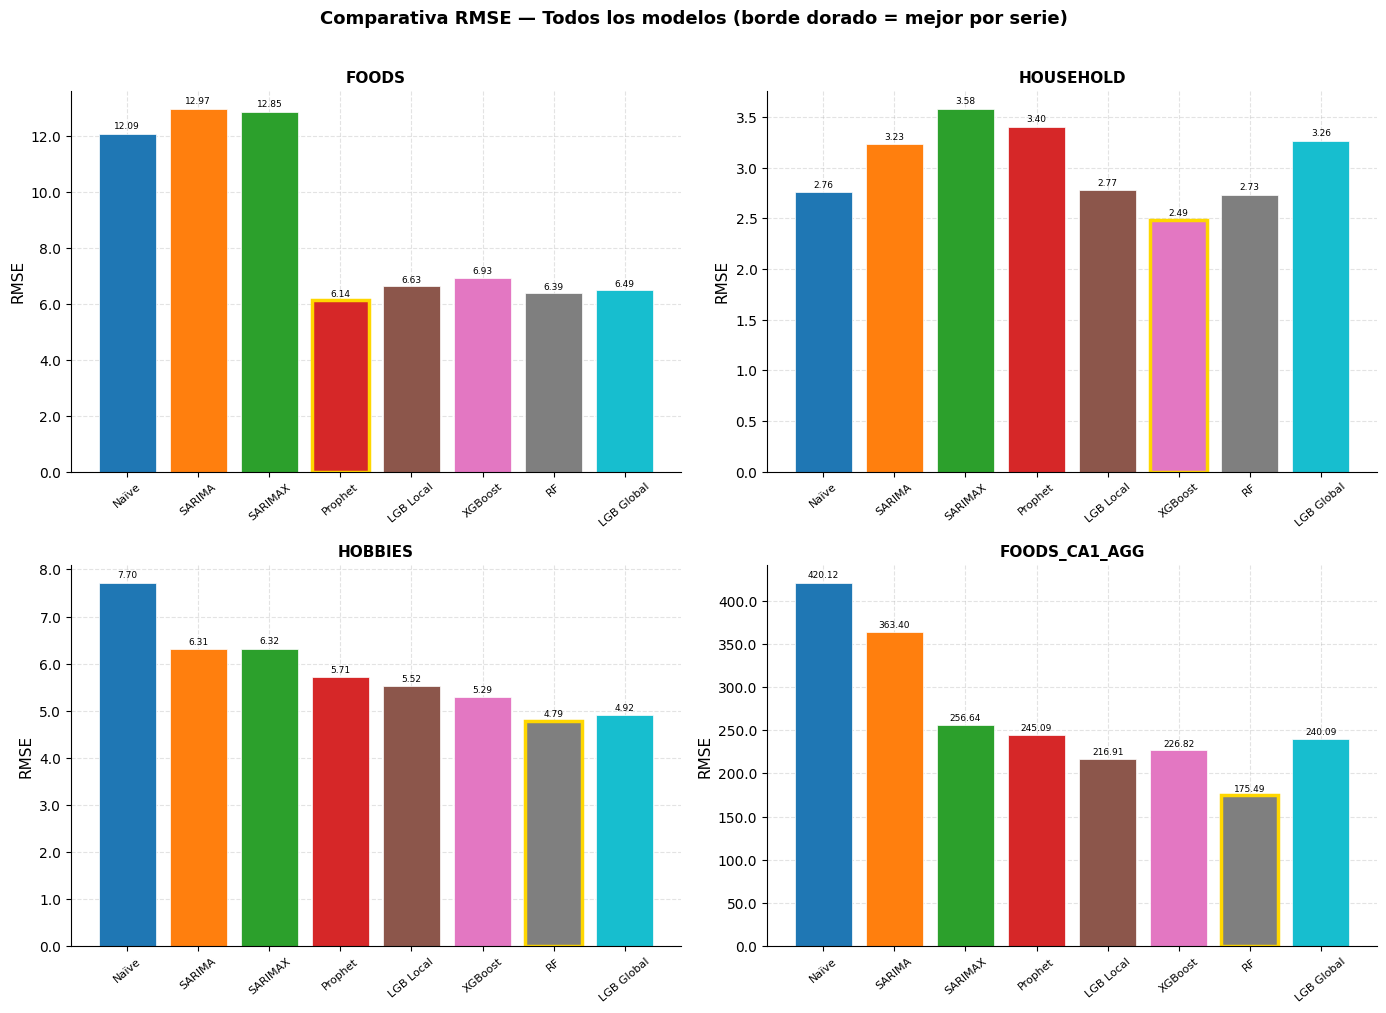

 fig_rmse_comparativa.png
Feature importance (sum debe ser ~1.0):
 LGB Local : 1.0000
 LGB Global: 1.0000
 XGBoost  : 1.0000


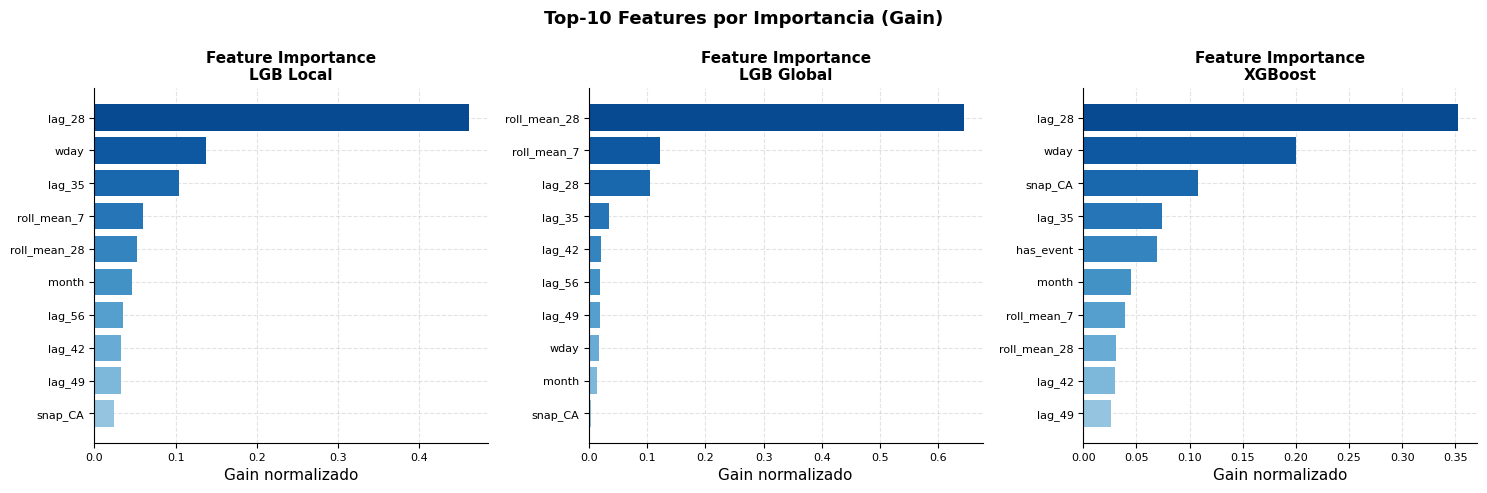

 fig_feature_importance.png


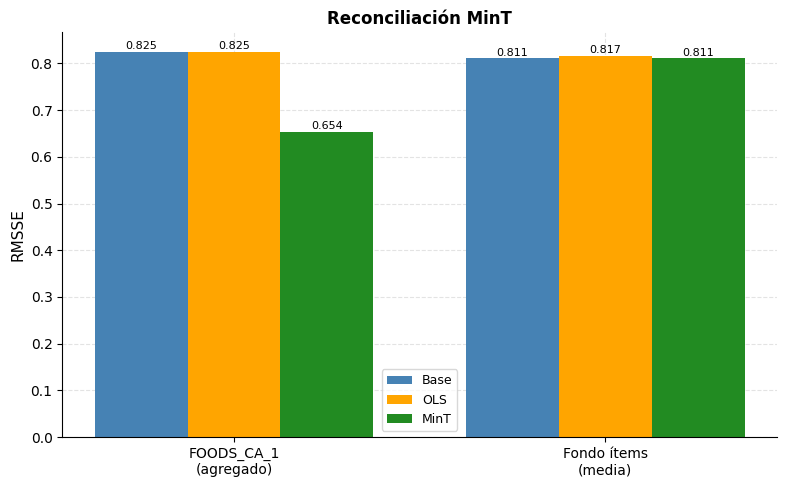


Figuras guardadas en imagenes\media
WRMSSE Global: 0.9323


In [23]:
# Tabla consolidada + figuras finales

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Tabla consolidada RMSE
models_order = [
    'Naïve', 'SARIMA', 'SARIMAX', 'Prophet',
    'LGB Local', 'XGBoost', 'RF', 'LGB Global'
]

results_all = {
    'Naïve': results_naive,
    'SARIMA': results_sarima,
    'SARIMAX': results_sarimax,
    'Prophet': results_prophet,
    'LGB Local': results_lgb,
    'XGBoost': results_xgb,
    'RF': results_rf,
    'LGB Global': results_lgb_global,
}

preds_all = {
    'Naïve': naive_preds,
    'SARIMA': sarima_preds,
    'SARIMAX': sarimax_preds,
    'Prophet': prophet_preds,
    'LGB Local': lgb_preds,
    'XGBoost': xgb_preds,
    'RF': rf_preds,
    'LGB Global': lgb_global_preds,
}

series_labels = list(rep_series.keys())
metrics = ['RMSE', 'MAE', 'MAPE']

# Imprimir tabla RMSE
print('TABLA CONSOLIDADA — RMSE (28 días de validación)')

hdr = f"{'Modelo':<12}" + ''.join(f'{s:>16}' for s in series_labels)
print(hdr)


for mod in models_order:
    row = f'{mod:<12}'
    for s in series_labels:
        v = results_all[mod][s]['RMSE']
        row += f'{v:>16.3f}'
    print(row)

print()

# Mejor modelo por serie
print('\nMejor modelo por serie (RMSE mínimo):')
for s in series_labels:
    best_mod = min(models_order, key=lambda m: results_all[m][s]['RMSE'])
    best_val = results_all[best_mod][s]['RMSE']
    print(f' {s:<16}: {best_mod} (RMSE={best_val:.3f})')


# Fig 1: Comparativa RMSE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors_bar = plt.cm.tab10(np.linspace(0, 0.9, len(models_order)))

for ax, sname in zip(axes, series_labels):
    vals = [results_all[m][sname]['RMSE'] for m in models_order]
    bars = ax.bar(models_order, vals, color=colors_bar, edgecolor='white', linewidth=0.5)

    best_i = int(np.argmin(vals))
    bars[best_i].set_edgecolor('gold')
    bars[best_i].set_linewidth(2.5)

    ax.set_title(sname, fontsize=11, fontweight='bold')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + bar.get_height()*0.01,
            f'{v:.2f}',
            ha='center', va='bottom', fontsize=6.5
        )

fig.suptitle(
    'Comparativa RMSE — Todos los modelos (borde dorado = mejor por serie)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_rmse_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()
print(' fig_rmse_comparativa.png')


# Fig 3: Feature Importance
lgb_imp = np.zeros(len(FEATURE_COLS))
for m in lgb_models.values():
    lgb_imp += m.feature_importance(importance_type='gain')
lgb_imp = lgb_imp / lgb_imp.sum()

lgb_g_imp_full = lgb_global.feature_importance(importance_type='gain').astype(float)
lgb_g_imp = lgb_g_imp_full[:len(FEATURE_COLS)]
lgb_g_imp = lgb_g_imp / lgb_g_imp.sum()

xgb_imp = np.zeros(len(FEATURE_COLS))
for m in xgb_models.values():
    sc = m.get_score(importance_type='gain')
    for fi, fname in enumerate(FEATURE_COLS):
        xgb_imp[fi] += sc.get(fname, 0)
xgb_imp = xgb_imp / max(xgb_imp.sum(), 1e-8)

print('Feature importance (sum debe ser ~1.0):')
print(f' LGB Local : {lgb_imp.sum():.4f}')
print(f' LGB Global: {lgb_g_imp.sum():.4f}')
print(f' XGBoost  : {xgb_imp.sum():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, imp) in zip(axes, [
    ('LGB Local', lgb_imp),
    ('LGB Global', lgb_g_imp),
    ('XGBoost', xgb_imp),
]):
    idx = np.argsort(imp)[-10:]
    colors_fi = plt.cm.Blues(np.linspace(0.4, 0.9, len(idx)))

    ax.barh([FEATURE_COLS[i] for i in idx], imp[idx], color=colors_fi)
    ax.set_title(f'Feature Importance\n{label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Gain normalizado')
    ax.tick_params(labelsize=8)

plt.suptitle('Top-10 Features por Importancia (Gain)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(' fig_feature_importance.png')


# Fig 5: MinT
fig, ax = plt.subplots(figsize=(8, 5))

cats_mint = ['FOODS_CA_1\n(agregado)', 'Fondo ítems\n(media)']
vals_base = [rm_agg_base, rm_bot_mean_base]
vals_ols = [rm_agg_ols, rm_bot_mean_ols]
vals_mint = [rm_agg_mint, rm_bot_mean_mint]

x_pos = np.arange(len(cats_mint))
w_bar = 0.25

ax.bar(x_pos - w_bar, vals_base, w_bar, label='Base', color='steelblue')
ax.bar(x_pos, vals_ols, w_bar, label='OLS', color='orange')
ax.bar(x_pos + w_bar, vals_mint, w_bar, label='MinT', color='forestgreen')

for i, (b, o, m) in enumerate(zip(vals_base, vals_ols, vals_mint)):
    for xi, v in [(i - w_bar, b), (i, o), (i + w_bar, m)]:
        ax.text(xi, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(cats_mint)
ax.set_ylabel('RMSSE')
ax.set_title('Reconciliación MinT', fontweight='bold')
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_mint.png', dpi=150)
plt.show()

print(f'\nFiguras guardadas en {FIGURES_DIR}')
print(f'WRMSSE Global: {WRMSSE_lgb_global:.4f}')